In [5]:
# библиотеки
import matplotlib.pyplot as plt
import numpy as np
import random
from IPython.display import clear_output

In [6]:
# Функции, которые не нужно менять

def look_cost (array, y, x, direction):
    
    if direction == 0:
        if x == 0: 
            return y, x
        elif (array[y][x-1][5] != 0 and array[y][x-1][4] < array[y][x][4]):
            return y, x-1
        

    elif direction == 2:
        if x == array.shape[0]-1: 
            return y, x
        elif (array[y][x+1][5] != 0 and array[y][x+1][4] < array[y][x][4]):
            return y, x+1
        

    elif direction == 1:
        if y == array.shape[0]-1: 
            return y, x
        elif (array[y+1][x][5] != 0 and array[y+1][x][4] < array[y][x][4]):
            return y+1, x
        

    elif direction == 3:
        if y == 0: 
            return y, x
        elif (array[y-1][x][5] != 0 and array[y-1][x][4] < array[y][x][4]):
            return y-1, x
    
    return y, x

def draw(array, y_r, x_r, y_t, x_t, y_s, x_s, path, number):
    n = array.shape[1]

    fig, ax = plt.subplots(figsize=(6, 6))

    for y in range(n):
        for x in range(n):
            left_wall, top_wall, right_wall, bottom_wall = array[y, x, :4]

            # путь
            if path:
                for py, px in path:
                    if (x == px and y == py):
                        ax.scatter(x, y, color='green', s=100)

            # состояние клетки
            if array[y][x][5] == 2:
                ax.fill_betweenx([y - 0.5, y + 0.5], x - 0.5, x + 0.5,
                                 color='blue', alpha=0.2)
            if array[y][x][5] == 3:
                ax.fill_betweenx([y - 0.5, y + 0.5], x - 0.5, x + 0.5,
                                 color='blue', alpha=0.5)

            # старт и цель
            if (x == x_s and y == y_s):
                ax.fill_betweenx([y - 0.5, y + 0.5], x - 0.5, x + 0.5,
                                 color='green', alpha=1)
            if (x == x_t and y == y_t):
                ax.fill_betweenx([y - 0.5, y + 0.5], x - 0.5, x + 0.5,
                                 color='red', alpha=1)

            # стены
            if left_wall:
                ax.plot([x - 0.5, x - 0.5], [y - 0.5, y + 0.5], 'k', lw=2)
            if top_wall:
                ax.plot([x - 0.5, x + 0.5], [y + 0.5, y + 0.5], 'k', lw=2)
            if right_wall:
                ax.plot([x + 0.5, x + 0.5], [y - 0.5, y + 0.5], 'k', lw=2)
            if bottom_wall:
                ax.plot([x - 0.5, x + 0.5], [y - 0.5, y - 0.5], 'k', lw=2)

            # робот
            if (x == x_r and y == y_r):
                img = plt.imread('robot.png')
                ax.imshow(img, extent=[x - 0.4, x + 0.4, y - 0.4, y + 0.4])

            # стоимость
            ax.text(x, y, int(array[y][x][4]),
                    ha='center', va='center', fontsize=10, color='gray')

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)
    ax.set_aspect('equal')
    ax.axis('off')

    # сохранение кадра
    path_to_img = f'Images_for_a/{number}.png'
    fig.savefig(path_to_img, dpi=150, bbox_inches='tight')
    clear_output(wait=True)
    plt.show()
    plt.show()
    plt.close(fig)
    return number + 1

In [7]:


# A_array[y][x][0] - направление влево, если 0 = стенки нет, если 1 = стенка
# A_array[y][x][1] - направление вниз, если 0 = стенки нет, если 1 = стенка
# A_array[y][x][2] - направление вправо, если 0 = стенки нет, если 1 = стенка
# A_array[y][x][3] - направление вверх, если 0 = стенки нет, если 1 = стенка
# A_array[y][x][4] - общая стоимость клетки, если она равна нулю, то мы туда еще ничего не писали
# A_array[y][x][5] - флаг состояния клетки (2 - доступная для движения; 3 - робот сейчас в ней)


# Функция, которую Вам нужно написать самостоятельно

def recount_cost(array, y, x, direction, y_t, x_t):

    # 0 - влево
    if direction == 0:
        if x == 0:
            return array

        extra_cost = abs(y_t - y) + abs(x_t - (x - 1))
        total_cost = array[y][x][4] + extra_cost + 1

        if (array[y][x - 1][4] == 0 or array[y][x - 1][4] > total_cost):
            array[y][x - 1][4] = total_cost
            array[y][x - 1][5] = 2
        return array

    # 2 - вправо
    elif direction == 2:
        if x == array.shape[1] - 1:
            return array

        extra_cost = abs(y_t - y) + abs(x_t - (x + 1))
        total_cost = array[y][x][4] + extra_cost + 1

        if (array[y][x + 1][4] == 0 or array[y][x + 1][4] > total_cost):
            array[y][x + 1][4] = total_cost
            array[y][x + 1][5] = 2
        return array

    # 1 - вниз (по логике твоего кода это y + 1)
    elif direction == 1:
        if y == array.shape[0] - 1:
            return array

        extra_cost = abs(y_t - (y + 1)) + abs(x_t - x)
        total_cost = array[y][x][4] + extra_cost + 1

        if (array[y + 1][x][4] == 0 or array[y + 1][x][4] > total_cost):
            array[y + 1][x][4] = total_cost
            array[y + 1][x][5] = 2
        return array

    # 3 - вверх (по логике твоего кода это y - 1)
    elif direction == 3:
        if y == 0:
            return array

        extra_cost = abs(y_t - (y - 1)) + abs(x_t - x)
        total_cost = array[y][x][4] + extra_cost + 1

        if (array[y - 1][x][4] == 0 or array[y - 1][x][4] > total_cost):
            array[y - 1][x][4] = total_cost
            array[y - 1][x][5] = 2
        return array

    return array

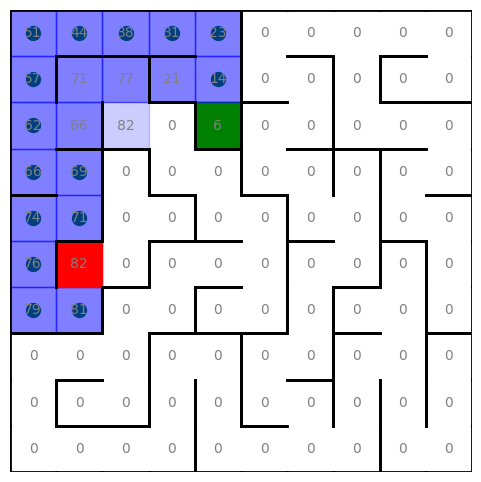

In [8]:
# Тело программы

try:
       data = np.loadtxt('adj_matrix.txt', dtype=int)
except Exception as e:
       print(f"Error loading file: {e}")
       exit()
# Определяем размерность m
num_rows = data.shape[0]
m = int(np.sqrt(num_rows))  # Извлекаем корень квадратный, так как у нас массив m x m
# Восстанавливаем исходный массив
labirint = data.reshape(m, m, 4)

A_array = np.zeros((m, m, 6))
A_array[:, :, :4] = labirint
A_array = A_array*0.1

number = 0

# Рисуем лабиринт, стартовую позицию робота и цель

plt.figure(figsize=(m, m))

# Позиция цели
y_target = int(random.uniform(0, m))
x_target = int(random.uniform(0, m))
print(x_target, y_target)


# Позиция робота
y_start = y_robot = int(random.uniform(0, m))
x_start = x_robot = int(random.uniform(0, m))
A_array[y_start][x_start][4] = abs((y_target) - y_start) + abs(x_target - x_start)
print('start pos', [y_robot, x_robot])

number = draw(A_array, y_robot, x_robot, y_target, x_target, y_start, x_start, [], number)

Flag_go_to_target = 1
Flag_go_back = 0
path = [[y_target, x_target]]  # Список для хранения пути

while Flag_go_to_target:  # Цикл продолжается, пока флаг движения к цели установлен
    
    for direction in range(0, 4, 1):  # Перебор всех направлений
        
        if A_array[y_robot][x_robot][direction] == 0:  # Проверяем, доступно ли движение в данном направлении
            
            # Вызываем функцию пересчета стоимости для текущего положения робота и направления
            A_array = recount_cost(A_array, y_robot, x_robot, direction, y_target, x_target)
    A_array[y_robot][x_robot][5] = 3  # Устанавливаем флаг: 3 значит, что  робот сейчас здесь
    
    
    
    min_distance = np.inf  # Инициализация минимального расстояния (большое значение)
    # Проходим по всему массиву A_array для поиска клетки с минимальной стоимостью, чтоб попытаться поместить робота в нее
    
    for y in range(0, m, 1):  # Перебор по всем строкам массива
        for x in range(0, m, 1):  # Перебор по всем столбцам массива


            if (A_array[y][x][5] == 2):  # Проверяем, помечена ли клетка как доступная для движения
                if (A_array[y][x][4] < min_distance):  # Если стоимость меньше текущего минимального расстояния
                    min_distance = A_array[y][x][4]  # Обновляем минимальное расстояние
                    # Обновляем координаты робота
                    y_robot = y  
                    x_robot = x

    # Вызов функции для отрисовки текущего состояния с новым положением робота и целевой позицией
    number = draw(A_array, y_robot, x_robot, y_target, x_target, y_start, x_start, [], number)

    # Проверяем, достиг ли робот целевой позиции
    if ([y_robot, x_robot] == [y_target, x_target]): 
        Flag_go_to_target = 0  # Если достигнута цель, останавливаем движение к цели
        Flag_go_back = 1  # Устанавливаем флаг для возвращения


while Flag_go_back:

    if [y_robot, x_robot] == [y_start, x_start]:
        Flag_go_back = 0

    for direction in range (0, 4, 1):
        if A_array[y_robot][x_robot][direction] == 0:
            y_robot, x_robot= look_cost(A_array, y_robot, x_robot, direction)
            if([y_robot, x_robot] != path[-1]): 
                path.append([y_robot, x_robot])

    number = draw(A_array, y_robot, x_robot, y_target, x_target, y_start, x_start, path, number)

image_folder = 'Images_for_a'